# Economic Dispatch LP with Renewables and Storage
This notebook contains an Economic Dispatch LP that includes Solar and Wind generators plus energy storage solved for 24 hours.

We will compare two objectives: **economic** (minimize operating cost) and **environmental** (minimize carbon emissions), then later combine them.

In [1]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Define the model and data

Decision variables:
* $P_{g,t}$ denotes the power output of thermal generator $g$ at hour $t$.
* $P_{s,t}$ denotes the solar ($s$) power output *utilized* at hour $t$.
* $P_{w,t}$ denotes the wind ($w$) power output *utilized* at hour $t$.
* $P_{ch,t}$ denotes the battery charging ($ch$) power at hour $t$.
* $P_{dis,t}$ denotes the battery discharging ($dis$) power at hour $t$.

Other fixed and derived values:
* $c_g$ denotes the cost per MWh of power output of generator $g$.
* $c_B$ denotes the battery throughput/degradation cost per MWh.
* $S_t^{avail}$ is the available solar power at hour $t$.
* $W_t^{avail}$ is the available wind power at hour $t$.
* $P_g^{max}$ is the maximum power output allowable for thermal generator $g$. $P_g^{min}$ is zero.
* $P_{ch}^{max}$ is the maximum battery charging power at any time.
* $P_{dis}^{max}$ is the maximum battery discharging power at any time.
* $E_t$ denotes the energy stored in the battery *at the end* of hour $t$.
* $E^{max}$ is the maximum battery energy capacity.
* $E^{init}$ is the initial energy stored in the battery.
* $\eta_{ch}$ is the battery charging efficiency.
* $\eta_{dis}$ is the battery discharging efficiency. 
* $D_t$ is the demand at hour $t$.
* $\Delta t$ is the duration of each period which is 1 hour.

In [2]:
# 24-hour time horizon
T = range(1, 25)

# Hourly demand (MW)
demand = {
     1: 140,  2: 135,  3: 130,  4: 128,
     5: 130,  6: 140,  7: 155,  8: 170,
     9: 180, 10: 185, 11: 190, 12: 195,
    13: 190, 14: 185, 15: 180, 16: 185,
    17: 195, 18: 210, 19: 220, 20: 215,
    21: 200, 22: 180, 23: 160, 24: 150
}

# Available solar generation (MW)
solar_available = {
     1: 0,    2: 0,   3: 0,   4: 0,
     5: 0,    6: 5,   7: 15,  8: 30,
     9: 50,  10: 70, 11: 85, 12: 95,
    13: 100, 14: 90, 15: 75, 16: 55,
    17: 30,  18: 10, 19: 0,  20: 0,
    21: 0,   22: 0,  23: 0,  24: 0
}

# Available wind generation (MW)
wind_available = {
     1: 55,  2: 60,  3: 65,  4: 60,
     5: 55,  6: 50,  7: 45,  8: 40,
     9: 35, 10: 35, 11: 40, 12: 45,
    13: 50, 14: 55, 15: 60, 16: 65,
    17: 70, 18: 70, 19: 65, 20: 60,
    21: 60, 22: 55, 23: 55, 24: 55
}

# Dispatchable generators
generators = ["Coal", "Gas", "Diesel"]

# Maximum generator output (MW)
Pmax = {
    "Coal":   120,
    "Gas":    100,
    "Diesel":  60
}

# Generation costs ($/MWh)
gen_cost = {
    "Coal":   35,
    "Gas":    60,
    "Diesel": 100
}

# Battery parameters
Emax = 60.0       # Battery energy capacity (MWh)
Pcharge_max = 20.0 # Maximum charging power (MW)
Pdis_max = 20.0    # Maximum discharging power (MW)

eta_charge = 0.90
eta_discharge = 0.90

E_initial = 30.0   # Initial stored energy (MWh)

# Small battery degradation / throughput cost
battery_cost = 1.0  # $/MWh

model = pyo.ConcreteModel()

model.T = pyo.RangeSet(1, 24)
model.G = pyo.Set(initialize=generators)

print("Model created.")

Model created.


In [3]:
# Thermal generator outputs
model.Pg = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)

# Renewable power actually used
model.Psolar = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.Pwind = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# Battery charging/discharging
model.Pcharge = pyo.Var(model.T, domain=pyo.NonNegativeReals, bounds=(0, Pcharge_max))
model.Pdischarge = pyo.Var(model.T, domain=pyo.NonNegativeReals, bounds=(0, Pdis_max))

# Battery state of charge
# Includes t = 0 because we need the initial state
model.E = pyo.Var(
    pyo.RangeSet(0, 24),
    domain=pyo.NonNegativeReals,
    bounds=(0, Emax)
)

print("Decision variables defined.")

Decision variables defined.


## 2. Model Formulation

### Objective Function
Our goal is to minimize the total operating cost over 24 hours:
$$ \min \sum_{t=1}^{24} \left[ \sum_g c_g P_{g,t} + c_B \left( P_{ch,t} + P_{dis,t} \right) \right] $$

### Constraints
Power balance at every hour $t$:

$$ P_{s,t} + P_{w,t} + P_{dis,t} + \sum_g P_{g,t} = D_t + P_{ch,t} $$

Utilized solar and wind power must not exceed the available power:

$$ 0 \leq P_{s,t} \leq S_t^{avail} $$
$$ 0 \leq P_{w,t} \leq W_t^{avail} $$

Thermal generator limits and battery limits:

$$ 0 \leq P_{g,t} \leq P_g^{max} $$
$$ 0 \leq P_{ch,t} \leq P_{ch}^{max} $$
$$ 0 \leq P_{dis,t} \leq P_{dis}^{max} $$

Battery state of charge equation:

$$ E_t = E_{t-1} + \eta_{ch} P_{ch,t} \Delta t - \frac{P_{dis,t} \Delta t}{\eta_{dis}}$$

Other battery constraints and boundary conditions:

$$ 0 \leq E_t \leq E^{max} $$
$$ E_{24} = E_0 $$ 

In [4]:
def total_cost(model):

    generation_cost = sum(
        gen_cost[g] * model.Pg[g, t]
        for g in model.G
        for t in model.T
    )

    battery_degradation_cost = sum(
        battery_cost * (model.Pcharge[t] + model.Pdischarge[t])
        for t in model.T
    )

    return generation_cost + battery_degradation_cost


model.objective = pyo.Objective(
    rule=total_cost,
    sense=pyo.minimize
)
print("Objective function specified.")

Objective function specified.


In [5]:
# Power balance
def power_balance_rule(model, t):
    thermal = sum(model.Pg[g, t] for g in model.G)
    supply = (thermal + model.Psolar[t] + model.Pwind[t] + model.Pdischarge[t])
    consumption = (demand[t] + model.Pcharge[t])
    return supply == consumption

model.power_balance = pyo.Constraint(model.T, rule=power_balance_rule)

# Generator capacity limits
def generator_capacity_rule(model, g, t):
    return model.Pg[g, t] <= Pmax[g]

model.generator_capacity = pyo.Constraint(model.G, model.T, rule=generator_capacity_rule)

# Solar availability
def solar_balance_rule(model, t):
    return model.Psolar[t] <= solar_available[t]
    
model.solar_balance = pyo.Constraint(model.T, rule=solar_balance_rule)

# Wind availability
def wind_balance_rule(model, t):
    return model.Pwind[t] <= wind_available[t]

model.wind_balance = pyo.Constraint(model.T, rule=wind_balance_rule)


# Initial battery energy
model.initial_energy = pyo.Constraint(expr=model.E[0] == E_initial)

# Battery energy balance
def battery_balance_rule(model, t):
    return model.E[t] == (model.E[t-1] + eta_charge * model.Pcharge[t] - model.Pdischarge[t] / eta_discharge)

model.battery_balance = pyo.Constraint(model.T, rule=battery_balance_rule)

# Final battery energy
model.final_energy = pyo.Constraint(expr=model.E[24] == E_initial)

print("Constraints specified.")

Constraints specified.


## 3. Solve the LP

In [6]:
solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=True)

results_data = []

for t in model.T:

    results_data.append({
        "Hour": t,
        "Demand": demand[t],
        "Coal": pyo.value(model.Pg["Coal", t]),
        "Gas": pyo.value(model.Pg["Gas", t]),
        "Diesel": pyo.value(model.Pg["Diesel", t]),
        "Solar": pyo.value(model.Psolar[t]),
        "Wind": pyo.value(model.Pwind[t]),
        "Charge": pyo.value(model.Pcharge[t]),
        "Discharge": pyo.value(model.Pdischarge[t]),
        "Battery Energy": pyo.value(model.E[t])
    })


df = pd.DataFrame(results_data)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Karl\AppData\Local\Temp\tmpcf8z8ajw.glpk.raw --wglp C:\Users\Karl\AppData\Local\Temp\tmpri2dpo_h.glpk.glp
 --cpxlp C:\Users\Karl\AppData\Local\Temp\tmp083ufjjr.pyomo.lp
Reading problem data from 'C:\Users\Karl\AppData\Local\Temp\tmp083ufjjr.pyomo.lp'...
170 rows, 193 columns, 386 non-zeros
1218 lines were read
Writing problem data to 'C:\Users\Karl\AppData\Local\Temp\tmpri2dpo_h.glpk.glp'...
1091 lines were written
GLPK Simplex Optimizer 5.0
170 rows, 193 columns, 386 non-zeros
Preprocessing...
48 rows, 156 columns, 227 non-zeros
Scaling...
 A: min|aij| =  9.000e-01  max|aij| =  1.111e+00  ratio =  1.235e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 48
      0: obj =   1.451800000e+05 inf =   1.309e+03 (25)
     28: obj =   1.773203333e+05 inf =   0.000e+00 (0)
*   109: obj =   7.649400000e+04 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Tim

In [7]:
print(df.round(2))
print()
print(f"Total operating cost = ${pyo.value(model.objective):,.2f}")

    Hour  Demand    Coal   Gas  Diesel  Solar  Wind  Charge  Discharge  \
0      1     140   85.00   0.0     0.0    0.0  55.0    0.00        0.0   
1      2     135   75.00   0.0     0.0    0.0  60.0    0.00        0.0   
2      3     130   65.00   0.0     0.0    0.0  65.0    0.00        0.0   
3      4     128   68.00   0.0     0.0    0.0  60.0    0.00        0.0   
4      5     130   75.00   0.0     0.0    0.0  55.0    0.00        0.0   
5      6     140   85.00   0.0     0.0    5.0  50.0    0.00        0.0   
6      7     155   95.00   0.0     0.0   15.0  45.0    0.00        0.0   
7      8     170  100.00   0.0     0.0   30.0  40.0    0.00        0.0   
8      9     180   95.00   0.0     0.0   50.0  35.0    0.00        0.0   
9     10     185   80.00   0.0     0.0   70.0  35.0    0.00        0.0   
10    11     190   65.00   0.0     0.0   85.0  40.0    0.00        0.0   
11    12     195   55.00   0.0     0.0   95.0  45.0    0.00        0.0   
12    13     190   40.00   0.0     0.0

## Plot results

Minimizing Operating Cost


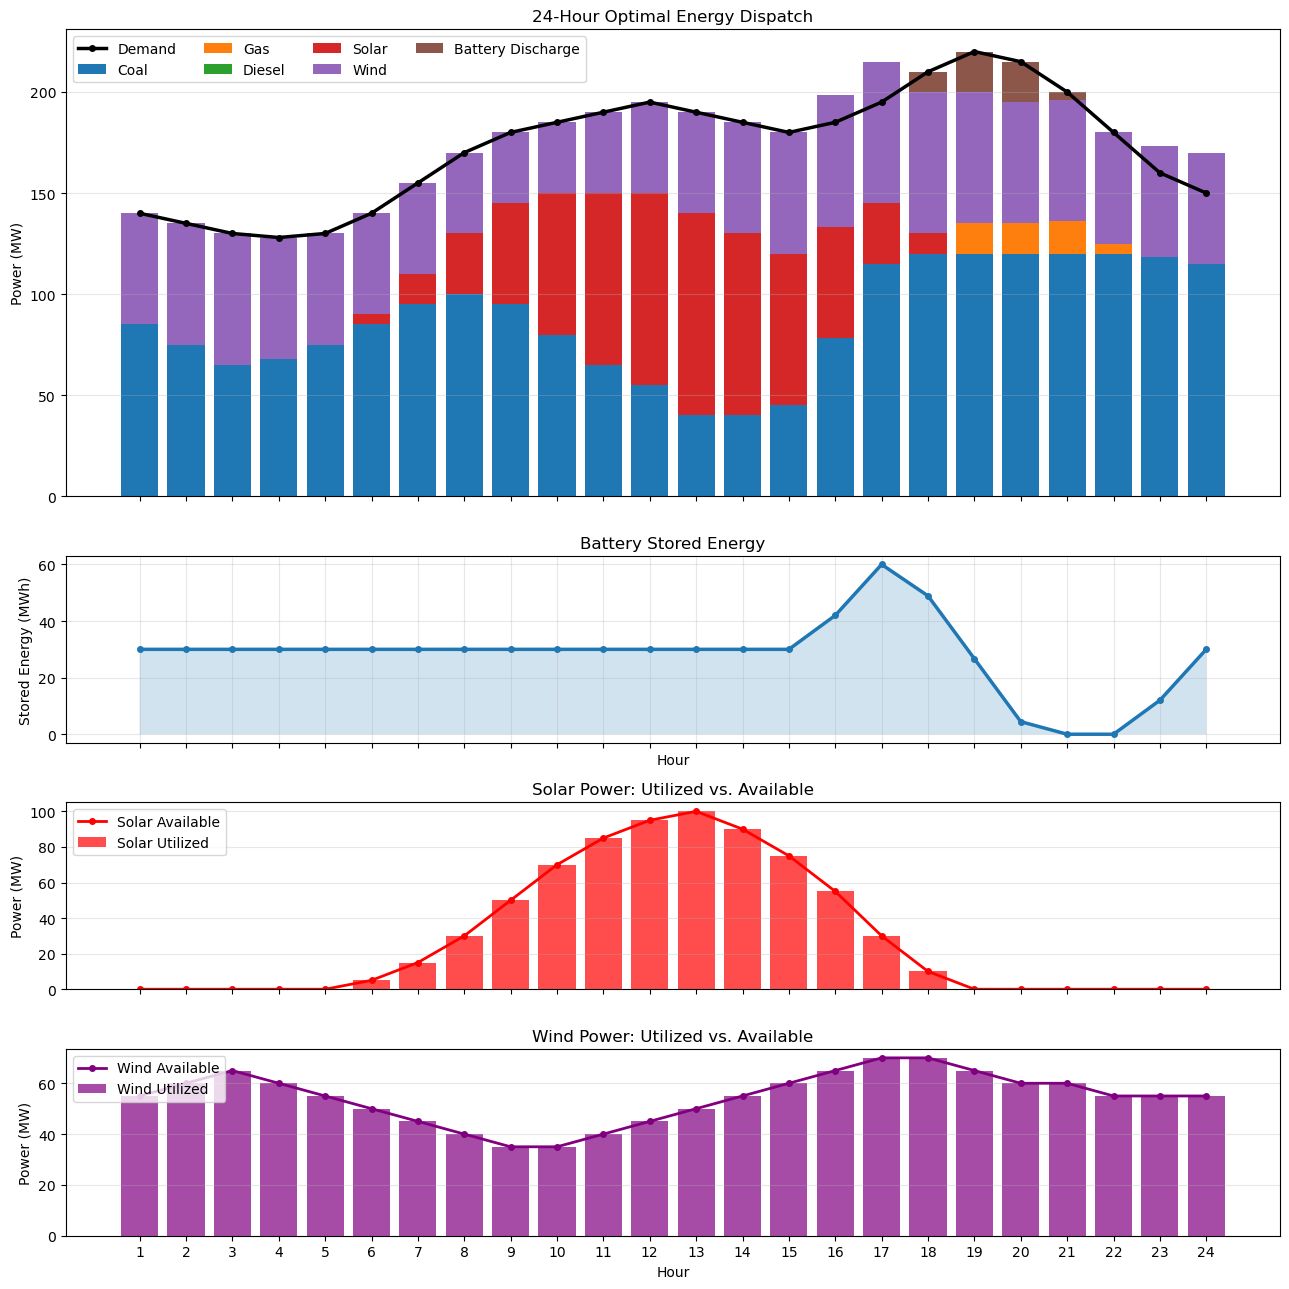

In [8]:
def plot_results(df):
    hours = df["Hour"]
    width = 0.8
    
    # Energy supplied to the grid
    energy_mix = df[["Coal", "Gas", "Diesel", "Solar", "Wind", "Discharge"]]
    sources = ["Coal", "Gas", "Diesel", "Solar", "Wind", "Discharge"]
    labels = ["Coal", "Gas", "Diesel", "Solar", "Wind", "Battery Discharge"]
    
    solar_avail = np.array([solar_available[t] for t in hours])
    wind_avail = np.array([wind_available[t] for t in hours])
    
    fig, ax = plt.subplots(4, 1, figsize=(13, 13),
        sharex=True, gridspec_kw={"height_ratios": [2.5, 1, 1, 1]})
    
    
    # ENERGY MIX + DEMAND
    bottom = np.zeros(len(df))
    for source, label in zip(sources, labels):
        ax[0].bar(hours, df[source], width=width, bottom=bottom, label=label)
        bottom += df[source].values
    
    # Demand line
    ax[0].plot(hours, df["Demand"], marker="o", color="k",
        linewidth=2.5, markersize=4, label="Demand")
    ax[0].set_ylabel("Power (MW)")
    ax[0].set_title("24-Hour Optimal Energy Dispatch")
    ax[0].legend(loc="upper left", ncol=4)
    ax[0].grid(axis="y", alpha=0.3)
    
    # BATTERY STATE OF CHARGE
    ax[1].plot(hours, df["Battery Energy"], linewidth=2.5, marker="o", markersize=4)
    ax[1].fill_between(hours, df["Battery Energy"], alpha=0.2)
    ax[1].set_xlabel("Hour")
    ax[1].set_ylabel("Stored Energy (MWh)")
    ax[1].set_title("Battery Stored Energy")
    ax[1].grid(alpha=0.3)
    ax[1].set_xticks(range(1, 25))
    
    # Solar utilized vs. available
    ax[2].bar(hours, df["Solar"], width=width,
        color="red", alpha=0.7, label="Solar Utilized")
    ax[2].plot(hours, solar_avail, color="red", marker="o",
        linewidth=2, markersize=4, label="Solar Available")
    ax[2].set_ylabel("Power (MW)")
    ax[2].set_title("Solar Power: Utilized vs. Available")
    ax[2].legend(loc="upper left")
    ax[2].grid(axis="y", alpha=0.3)
    
    # Wind utilizes vs. available
    ax[3].bar(hours, df["Wind"], width=width,
        color="purple", alpha=0.7, label="Wind Utilized")
    ax[3].plot(hours, wind_avail, color="purple",
        marker="o", linewidth=2, markersize=4, label="Wind Available")
    
    ax[3].set_xlabel("Hour")
    ax[3].set_ylabel("Power (MW)")
    ax[3].set_title("Wind Power: Utilized vs. Available")
    
    ax[3].legend(loc="upper left")
    ax[3].grid(axis="y", alpha=0.3)
    ax[3].set_xticks(range(1, 25))
    
    plt.tight_layout()
    plt.show()

print("Minimizing Operating Cost")
plot_results(df)

# Change the economic to environmental objective

Instead of cost minimization, we now try to minimize carbon emissions:

$$ \min \sum_{t=1}^{24} \sum_g e_g P_{g,t} \Delta t$$

where $e_g$ is the emission factor of generator $g$ in ton CO2/MWh.

In [9]:
emission_factor = {
    "Coal":   1.00,   # ton CO2 / MWh
    "Gas":    0.45,
    "Diesel": 0.75
}

def total_emissions(model):

    return sum(
        emission_factor[g] * model.Pg[g, t]
        for g in model.G
        for t in model.T
    )

# Remove the economic objective
model.del_component(model.objective)

model.objective = pyo.Objective(
    rule=total_emissions,
    sense=pyo.minimize
)

solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=True)
results_data = []

for t in model.T:
    results_data.append({
        "Hour": t,
        "Demand": demand[t],
        "Coal": pyo.value(model.Pg["Coal", t]),
        "Gas": pyo.value(model.Pg["Gas", t]),
        "Diesel": pyo.value(model.Pg["Diesel", t]),
        "Solar": pyo.value(model.Psolar[t]),
        "Wind": pyo.value(model.Pwind[t]),
        "Charge": pyo.value(model.Pcharge[t]),
        "Discharge": pyo.value(model.Pdischarge[t]),
        "Battery Energy": pyo.value(model.E[t])
    })


df2 = pd.DataFrame(results_data)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Karl\AppData\Local\Temp\tmpqw29bq69.glpk.raw --wglp C:\Users\Karl\AppData\Local\Temp\tmpff87xu3m.glpk.glp
 --cpxlp C:\Users\Karl\AppData\Local\Temp\tmpkdut8n4c.pyomo.lp
Reading problem data from 'C:\Users\Karl\AppData\Local\Temp\tmpkdut8n4c.pyomo.lp'...
170 rows, 193 columns, 386 non-zeros
1170 lines were read
Writing problem data to 'C:\Users\Karl\AppData\Local\Temp\tmpff87xu3m.glpk.glp'...
1043 lines were written
GLPK Simplex Optimizer 5.0
170 rows, 193 columns, 386 non-zeros
Preprocessing...
48 rows, 156 columns, 227 non-zeros
Scaling...
 A: min|aij| =  9.000e-01  max|aij| =  1.111e+00  ratio =  1.235e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 48
      0: obj =   4.148000000e+03 inf =   1.328e+03 (25)
     29: obj =   3.453450000e+03 inf =   0.000e+00 (0)
*   139: obj =   1.016812500e+03 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Tim

Minimizing CO2 Emissions


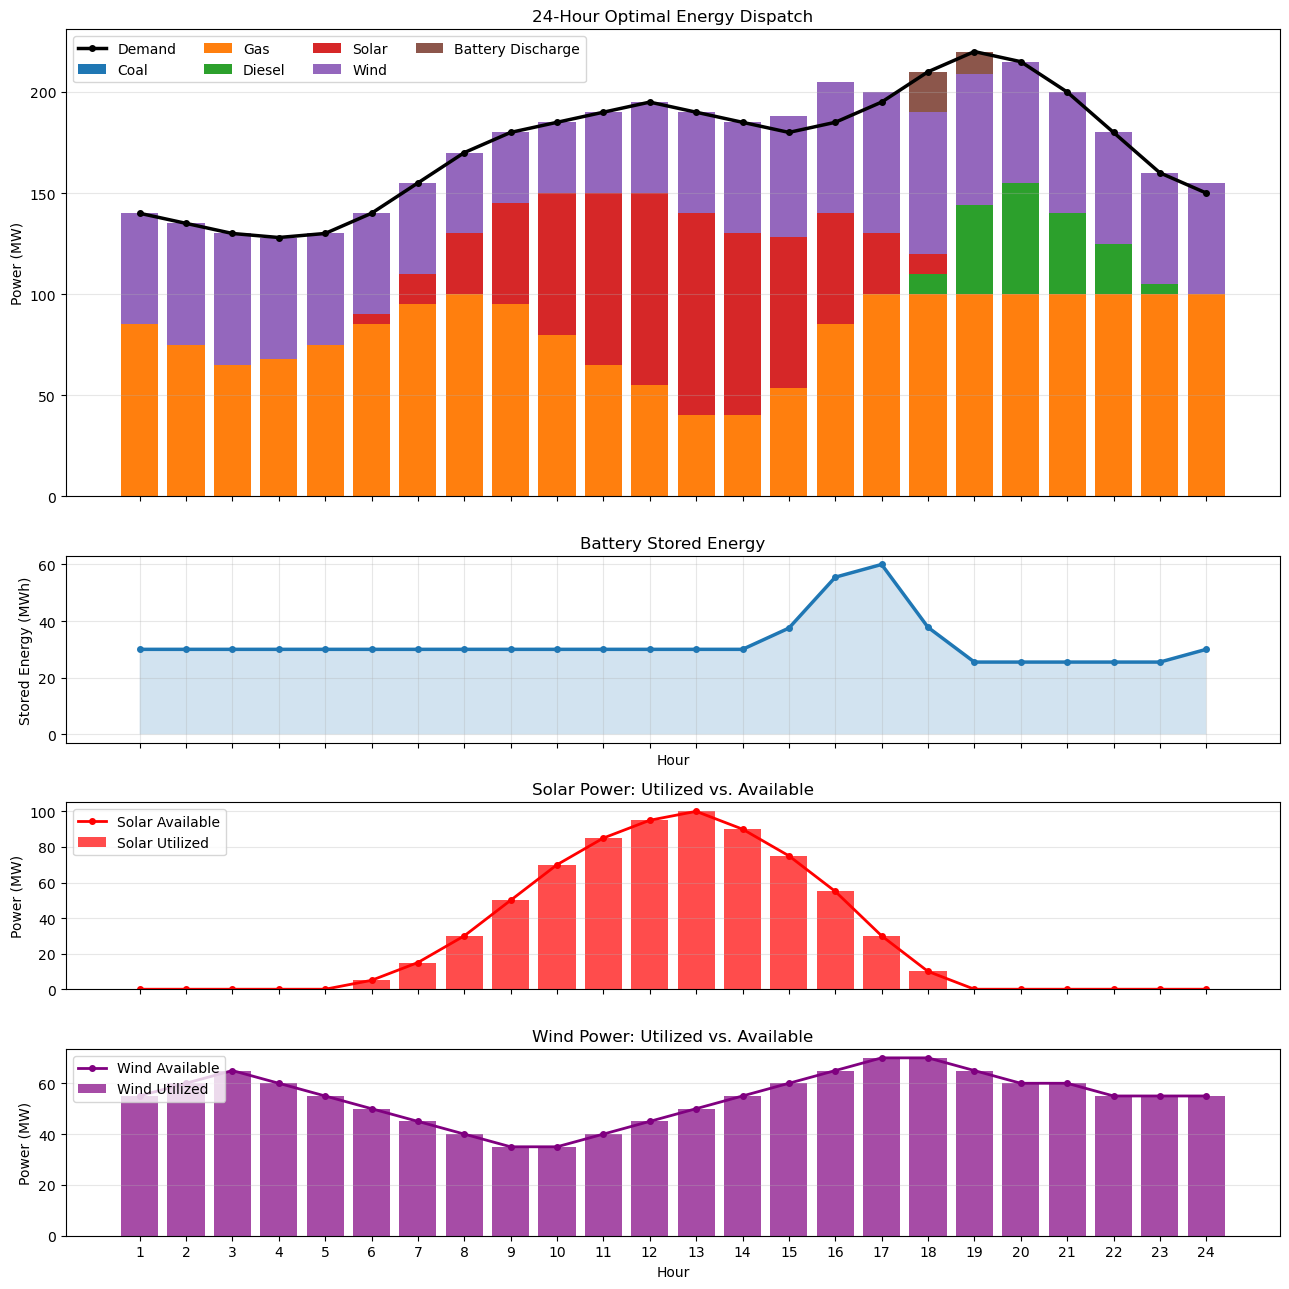

In [10]:
print("Minimizing CO2 Emissions")
plot_results(df2)

In [11]:
def evaluate(df):
    # Total operating cost
    cost = sum(gen_cost[g] * df[g].sum() for g in gen_cost)

    # Add battery throughput cost
    cost += (battery_cost * (df["Charge"].sum() + df["Discharge"].sum()))

    # Total carbon emissions
    emissions = sum(emission_factor[g] * df[g].sum() for g in emission_factor)

    return cost, emissions

# Economic scenario
cost_econ, emissions_econ = evaluate(df)

# Environmental scenario
cost_env, emissions_env = evaluate(df2)

print("ECONOMIC SCENARIO")
print(f"Operating Cost:   ${cost_econ:,.2f}")
print(f"Carbon Emissions: {emissions_econ:,.2f} ton CO2")

print()

print("ENVIRONMENTAL SCENARIO")
print(f"Operating Cost:   ${cost_env:,.2f}")
print(f"Carbon Emissions: {emissions_env:,.2f} ton CO2")

ECONOMIC SCENARIO
Operating Cost:   $76,494.00
Carbon Emissions: 2,117.62 ton CO2

ENVIRONMENTAL SCENARIO
Operating Cost:   $135,644.38
Carbon Emissions: 1,016.81 ton CO2


# Combined economic and environmental objective

We introduce a carbon tax rate $\tau$ to convert the tons of CO2 emissions into a cost. The new combined objective becomes:

$$ \min \sum_{t=1}^{24} \left[ \sum_g c_g P_{g,t} + c_B \left( P_{ch,t} + P_{dis,t} \right) + \tau \sum_g e_g P_{g,t} \Delta t \right] $$

where $\tau$ is the carbon tax rate in $ per ton CO2.

In [12]:
# Remove the economic objective
model.del_component(model.objective)

def combined_obj(model):
    tax_rate = 100
    return tax_rate * total_emissions(model) + total_cost(model)

model.objective = pyo.Objective(
    rule=combined_obj,
    sense=pyo.minimize
)

solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=True)
results_data = []

for t in model.T:
    results_data.append({
        "Hour": t,
        "Demand": demand[t],
        "Coal": pyo.value(model.Pg["Coal", t]),
        "Gas": pyo.value(model.Pg["Gas", t]),
        "Diesel": pyo.value(model.Pg["Diesel", t]),
        "Solar": pyo.value(model.Psolar[t]),
        "Wind": pyo.value(model.Pwind[t]),
        "Charge": pyo.value(model.Pcharge[t]),
        "Discharge": pyo.value(model.Pdischarge[t]),
        "Battery Energy": pyo.value(model.E[t])
    })


df3 = pd.DataFrame(results_data)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Karl\AppData\Local\Temp\tmpeyg2657v.glpk.raw --wglp C:\Users\Karl\AppData\Local\Temp\tmpm6p9ynuq.glpk.glp
 --cpxlp C:\Users\Karl\AppData\Local\Temp\tmpb14cp1hz.pyomo.lp
Reading problem data from 'C:\Users\Karl\AppData\Local\Temp\tmpb14cp1hz.pyomo.lp'...
170 rows, 193 columns, 386 non-zeros
1218 lines were read
Writing problem data to 'C:\Users\Karl\AppData\Local\Temp\tmpm6p9ynuq.glpk.glp'...
1091 lines were written
GLPK Simplex Optimizer 5.0
170 rows, 193 columns, 386 non-zeros
Preprocessing...
48 rows, 156 columns, 227 non-zeros
Scaling...
 A: min|aij| =  9.000e-01  max|aij| =  1.111e+00  ratio =  1.235e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 48
      0: obj =   5.599800000e+05 inf =   1.309e+03 (25)
     28: obj =   5.226653333e+05 inf =   0.000e+00 (0)
*   134: obj =   2.301676333e+05 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Tim

Minimizing Operating Cost AND CO2 Emissions


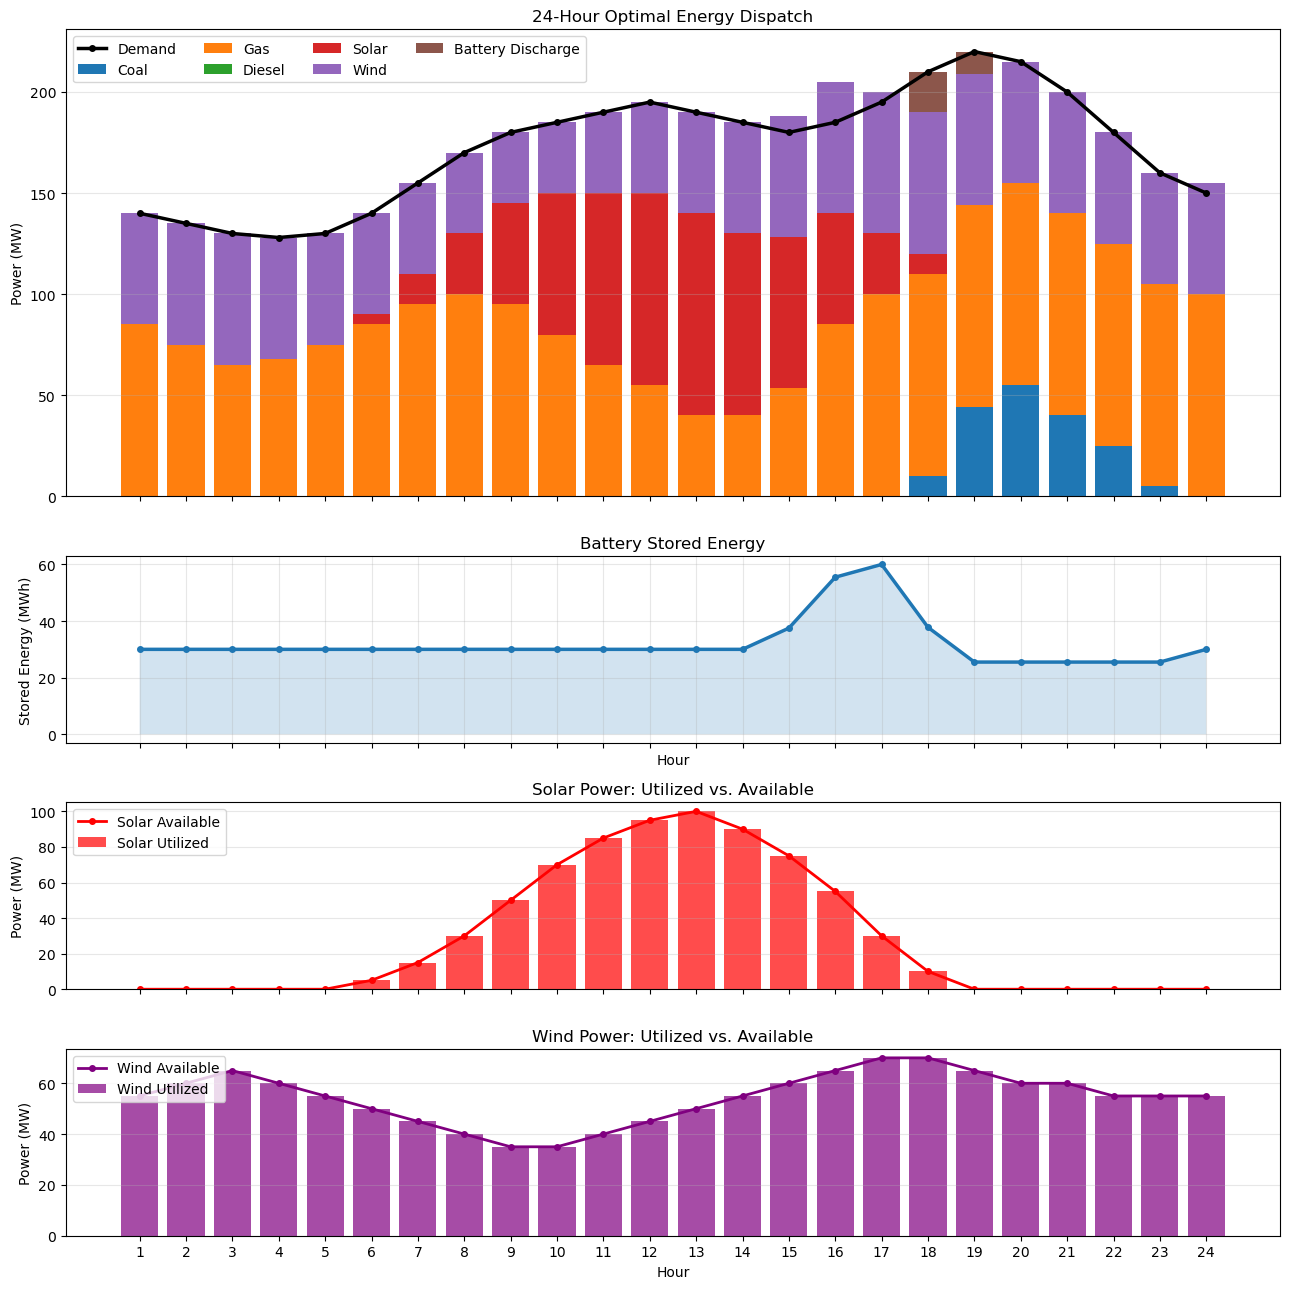

In [13]:
print("Minimizing Operating Cost AND CO2 Emissions")
plot_results(df3)

In [14]:
print("ECONOMIC SCENARIO")
print(f"Operating Cost:   ${cost_econ:,.2f}")
print(f"Carbon Emissions: {emissions_econ:,.2f} ton CO2")

print()

print("ENVIRONMENTAL SCENARIO")
print(f"Operating Cost:   ${cost_env:,.2f}")
print(f"Carbon Emissions: {emissions_env:,.2f} ton CO2")

print()

cost_comb, emissions_comb = evaluate(df3)
print("COMBINED SCENARIO")
print(f"Operating Cost:   ${cost_comb:,.2f}")
print(f"Carbon Emissions: {emissions_comb:,.2f} ton CO2")


ECONOMIC SCENARIO
Operating Cost:   $76,494.00
Carbon Emissions: 2,117.62 ton CO2

ENVIRONMENTAL SCENARIO
Operating Cost:   $135,644.38
Carbon Emissions: 1,016.81 ton CO2

COMBINED SCENARIO
Operating Cost:   $124,012.63
Carbon Emissions: 1,061.55 ton CO2
